<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/notebooks/pairwise_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This we are trying to understand
# How similar are 2 images?
# Appearance wise
# Meaning wise
# We will use similarity score

In [2]:
import skimage.io as io
from PIL import Image
from IPython.display import display

In [3]:
urls = ['https://github.com/andandandand/image-dataset-curation/blob/main/images/red_apple_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/red_apple_2.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/green_apple_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/green_apple_2.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/orange_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/orange_2.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/toy_car_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/toy_car_2.png?raw=true']

In [4]:
op = io.imread(urls[0])
print(type(op))
print(op.shape)

<class 'numpy.ndarray'>
(1024, 1024, 4)


In [5]:
# So there are 4 channels and size of image is 1024 by 1024
# skimage.io cpatures metadata of the image - size
# Converts image to numpy array

In [6]:
# To display the image we are using PIL Python Image library

In [7]:
pilop = Image.fromarray(op)
print(type(pilop))
print(pilop.size)

<class 'PIL.Image.Image'>
(1024, 1024)


In [8]:
pilop_rgb = pilop.convert('RGB')
print(type(pilop_rgb))
print(pilop_rgb.size)

<class 'PIL.Image.Image'>
(1024, 1024)


In [9]:
print(pilop_rgb.mode)
print(pilop.mode)
# A stands for Alpha - transparencey

RGB
RGBA


In [10]:
images = [
    Image.fromarray(
        io.imread(url)
    )
    for url in urls
]

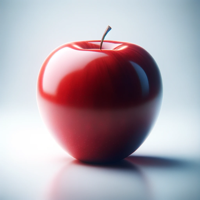

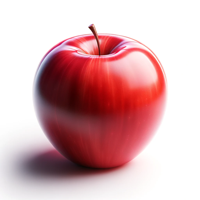

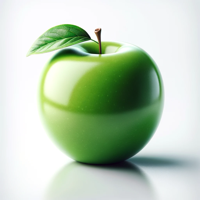

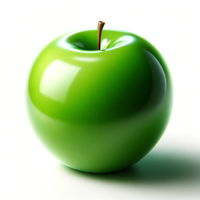

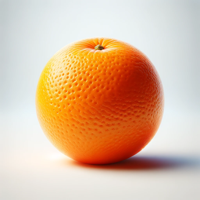

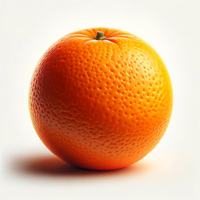

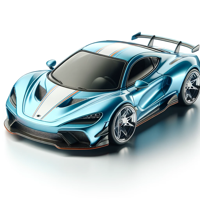

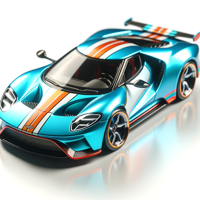

In [11]:
image_desired_sizes = (200,200)
for img in images:
  img = img.resize(image_desired_sizes)
  display(img)

In [12]:
# We are extracting embedding from ResNet trained NN

In [13]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models.resnet import ResNet34_Weights
from PIL import Image

In [14]:
model = models.resnet34(
    weights=ResNet34_Weights.IMAGENET1K_V1
)
# print(model)
# Model architecture loaded with trained weights


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 157MB/s]


In [15]:
# We want the last layer - classification layer
# The Flatten part of this classification layer

![](https://raw.githubusercontent.com/andandandand/image-dataset-curation/main/images/convolutional_network.png)


In [16]:
# list(model.children())[7:10]

In [17]:
# Get only the Flatten layer - remove final layer - classification layer

In [18]:
model = torch.nn.Sequential(
    *list(
        model.children()
    )[:-1]
)
print(model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [19]:
model.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [20]:
# We want to feed our image to this NN and get the embedding vector
# We need to transform our image first

In [21]:
transform = transforms.Compose(
    [
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ]
)
print(transform)

Compose(
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [22]:
# Create a function to create an embedding from image

In [23]:
def create_embedding_from_image(image_url):
  image_object = Image.fromarray(
      io.imread(image_url)
  ).convert('RGB')
  transformed_image = transform(image_object)
  # transformed_image.shape = (C, H, W)
  # Add batch dimension to existing CHW dimension
  transformed_image = transformed_image.unsqueeze(0)
  with torch.no_grad():
    image_embedding = model(transformed_image)
    return image_embedding.squeeze().numpy()

In [24]:
first_image_embedding = create_embedding_from_image(urls[0])
print(first_image_embedding.shape)

(512,)


In [25]:
print(first_image_embedding)

[2.35259652e-01 1.90896809e-01 1.46414250e-01 3.26690376e-02
 1.03104413e+00 8.31522867e-02 2.61795763e-02 7.41157711e-01
 1.03840911e+00 1.77700758e-01 2.07368106e-01 5.84200859e-01
 2.49355342e-02 7.37223700e-02 2.73409814e-01 9.72779170e-02
 2.03205630e-01 4.52352352e-02 3.64668667e-02 9.16149378e-01
 5.05652952e+00 4.96781766e-01 6.99132979e-02 2.70065339e-03
 1.65684316e-02 2.67489105e-02 3.38970453e-01 9.50047553e-01
 1.33926734e-01 1.13009202e+00 5.73803365e-01 2.15630680e-01
 8.83623306e-03 2.33472645e-01 6.95484459e-01 2.31781244e-01
 5.94725072e-01 0.00000000e+00 2.95050472e-01 3.07760209e-01
 5.59003711e-01 1.08968886e-02 2.37339199e-01 0.00000000e+00
 1.36505365e-01 6.99559450e-01 2.52895981e-01 4.91421556e+00
 8.57957006e-02 5.71591593e-02 4.24160242e-01 4.39346842e-02
 3.21407765e-01 2.21581891e-01 4.62542176e-01 6.48583174e-01
 1.30888477e-01 9.62161958e-01 2.12777942e-01 5.16956389e-01
 1.92014948e-01 8.02669898e-02 8.79263878e-01 3.04149487e-03
 1.60599843e-01 1.566964

In [26]:
# Compare image pairs with cosine similarity

In [27]:
# Why use cosine similarity over Euclidean distance or any other method
# https://share.google/aimode/aKy4IlcgfZuo0wzMu

In [28]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

In [29]:
def cosine_similarity(a, b):
  numerator = dot(a,b)
  denominator = norm(a)*norm(b)
  return numerator/denominator

In [30]:
vec1 = np.array(
    [1, 2, 3]
)
vec2 = np.array(
    [2, 4, 6]
)
print(vec1)
print(vec2)

[1 2 3]
[2 4 6]


In [31]:
csvec1vec2 = cosine_similarity(vec1, vec2)
print(csvec1vec2)


1.0


In [32]:
csimg1img2 = cosine_similarity(
    first_image_embedding,
    create_embedding_from_image(urls[1])
)
print(csimg1img2)

0.7617404


In [33]:
# I am creating a neat function to intake embeddings
# Get their similarity scores
# Print it out
# Plot the images

In [34]:
def print_cosine_similarity_scores(e1, e2):
  score = cosine_similarity(e1, e2)
  print(f"Cosine similarity score = {score}")


In [35]:
import matplotlib.pyplot as plt
def show_pair(img_a, img_b):
  plt.subplot(121)
  plt.imshow(np.array(img_a))
  plt.axis('off')
  plt.subplot(122)
  plt.imshow(np.array(img_b))
  plt.axis('off')

In [39]:
# Create a vector of all image embeddings
image_embeddings = [
    create_embedding_from_image(url) for url in urls
]

In [42]:
image_embeddings[0].shape


(512,)

In [43]:
# A slider to compare images


Cosine similarity score = 0.3227897882461548


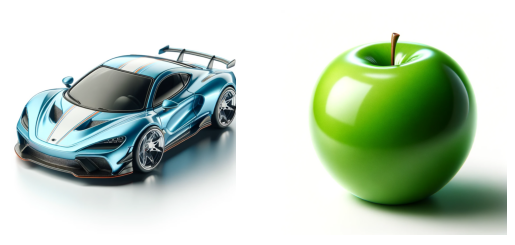

In [56]:
# @title {run:'auto'}
slider1 = 6 # @param {type: "slider", min: 0, max: 6}
slider2 = 3 # @param {type: "slider", min: 0, max: 6}
print_cosine_similarity_scores(
    image_embeddings[slider1],
    image_embeddings[slider2]
)
show_pair(images[slider1], images[slider2])